In [1]:
import argparse
import logging
import os
from pathlib import Path

import numpy as np
import torch
import yaml
from easydict import EasyDict as edict
from matplotlib import pyplot as plt
from tqdm import tqdm

from src.datasets import get_dataloaders
from src.datasets.augmentations import get_transforms
from src.utils.generic_utils import seed_everything
from src.visualizations import CLASS_COLORS, DEFAULT_COLOR

logging.basicConfig(level=logging.INFO)

parser = argparse.ArgumentParser()
parser.add_argument('-c', '--config_path', type=str, required=True, help='Configuration file path to start training from scratch')
parser.add_argument('-od', '--output_dir', type=str, required=True, help='Output directory where to write the visualizations')
parser.add_argument('-st', '--step_size', type=int, default=10, help='Every nth record to be visualized')
parser.add_argument('-s', '--sampling_only', action='store_true', default=False, help='Visualize only dataset examples where the sampler ')
parser.add_argument('-na', '--no_aug', action='store_true', default=False, help='Disable augmentations for visualization')
parser.add_argument('-la', '--label_agg_order', nargs='+', type=int, help='The order at which to overlay the classes masks.')
args_input = [
    '-c',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/fingerprint_tumors.yaml',
    '-od',
    '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours',
]
args = parser.parse_args(args_input)
args.config_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/configs/classification/kits_tumours/effv2s_kits_tumors.yaml'
# args.output_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/slice_dataset"
args.output_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/slice_dataset_test"
args.step_size = 1
args.no_aug = True


with open(args.config_path) as fid:
    opt = yaml.safe_load(fid)
    opt = edict(opt)
seed_everything(opt.seed)

print('Creating data loaders to be visualized...')
transforms = get_transforms(opt.dataset)
if args.no_aug:
    transforms['train'] = transforms['val']
params = edict(opt.dataset, use_sampler=False, reset_sampler=False, shuffle_test=False)
train_loader, test_loader = get_dataloaders(params, transforms)
print(f'Total number of samples: {len(train_loader.dataset) + len(test_loader.dataset)}')

print('saveing slice train and val set')

Creating data loaders to be visualized...
Using CT norm to change img from HU to [-1,1], no normalization applied in transforms(Aug)
Instantiated training dataset for number of samples: 25389
[KiTS dataset] Number of slices with positive sampling label: 5764
[Merged dataset] Number of slices with positive sampling label: 5764
[Merged dataset] Number of slices with negtive sampling label: 19625
Instantiated validation dataset for number of samples: 6216
[KiTS dataset] Number of slices with positive sampling label: 1195
[Merged dataset] Number of slices with positive sampling label: 1195
[Merged dataset] Number of slices with negtive sampling label: 5021
Total number of samples: 31605
saveing slice train and val set


In [6]:
from PIL import Image


def saveslices_dataset(
    dataset: torch.utils.data.Dataset, out_dir: str, step: int = 10, alpha=0.7, sampling_only: bool = False, agg_order: list[int] = None
) -> None:
    if hasattr(dataset, 'scans'):
        for s in dataset.scans:
            s.load_masks = True
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for sub_dir in ['images', 'masks']:
        (out_dir / sub_dir).mkdir(parents=True, exist_ok=True)

    inds = list(range(0, len(dataset), step)) if not sampling_only else np.nonzero(dataset.get_sampling_labels())[0][::step]
    print(f'Visualizing {len(inds)} samples...')
    for i in tqdm(inds):
        s = dataset[i]
        assert s['masks'].shape[0] > 0, f'No masks are loaded in the dataset: {dataset}'
        assert s['image'].min() >= -1.01 and s['image'].max() <= 1, f'Image range is not in [-1, 1]: {s["image"].min(), s["image"].max()}'
        name = dataset.split + '_' + s.get('scan_name', 'sample').split('.')[0] + '_label_' + str(s['label'].item())
        # print(f'input image range: {s["image"][0].min(), s["image"][0].max()}')
        img = ((s['image'][0].numpy() + 1) / 2) * 255
        img = np.stack([img.astype(np.uint8)] * 3, -1)
        # print(img.shape, s['scan_name'], s['slice_index'])

        # vis_mask = np.zeros((*s['masks'].shape[1:], 3), dtype=np.uint8)

        # for j in (agg_order or range(1, s['masks'].shape[0])):
        #     # print(s['masks'].shape, dataset.classes)
        #     class_name = dataset.classes[j]
        #     # class_name = '1'
        #     color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)
        #     # print(class_name, color)
        #     cl_mask = np.stack([s['masks'][j].numpy()]*3, -1).astype(np.uint8) * np.array(color).reshape(1, 1, 3)
        #     vis_mask = vis_mask + cl_mask
        # vis_mask = vis_mask.astype(np.uint8)
        # vis_img = (img*alpha).astype(np.uint8) + ((1-alpha)*vis_mask).astype(np.uint8) #blended image

        img_name = f"{s['scan_casename']}_slice{s['slice_index']}"
        name = f'{img_name}_label{str(s["label"].item())}'
        print(name)  # 0001_023.png(processed slice); 0001_023_mask.png
        if i >= 10:
            break
    return s, img
    # Image.fromarray(img).save(out_dir / 'images' / f'{name}.png')
    # Image.fromarray(vis_img).save(out_dir / 'masks' / f'{name}_mask.png')


s, img = saveslices_dataset(train_loader.dataset, args.output_dir, step=args.step_size, sampling_only=args.sampling_only, agg_order=args.label_agg_order)
print('train set saved')
# saveslices_dataset(test_loader.dataset, args.output_dir, step=args.step_size,
#                     sampling_only=args.sampling_only, agg_order=args.label_agg_order)

Visualizing 25389 samples...


  0%|          | 10/25389 [07:10<303:19:30, 43.03s/it] 

case_00423_slice16_label0
case_00423_slice17_label0
case_00423_slice18_label0
case_00423_slice19_label0
case_00423_slice20_label0
case_00423_slice21_label0
case_00423_slice22_label0
case_00423_slice23_label0
case_00423_slice24_label0
case_00423_slice25_label0
case_00423_slice26_label0
train set saved


Orig image range (tensor(-1.0000), tensor(1.0000))
Processed image range (0, 254)


Text(0.5, 1.0, 'Processed Image')

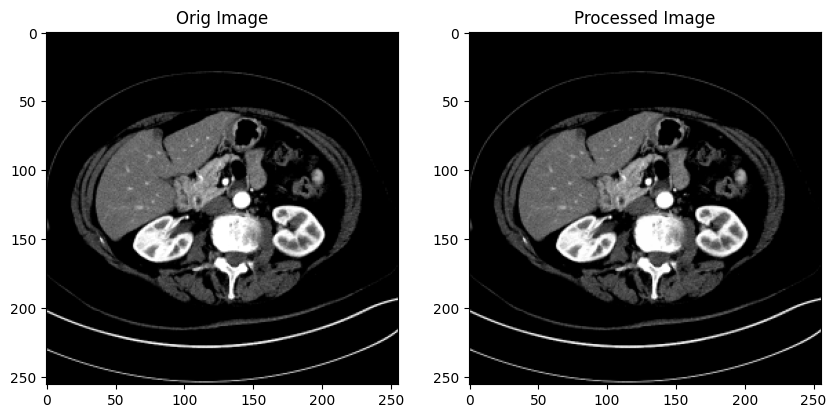

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
print(f"Orig image range {s['image'][0].min(), s['image'][0].max()}")
print(f"Processed image range {img.min(), img.max()}")
axes[0].imshow(s["image"][0], cmap='gray')
axes[0].set_title("Orig Image")

axes[1].imshow(img)
axes[1].set_title("Processed Image")